# This is for 6 mL : 4 mL ratio in room temperature

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
csv_path  =r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release.csv"
time_col  = "Time (s)"                     # your column is actually hours
press_col = "DWT denoised pressure (kPa)"  # pressure in kPa
gas_col   = "O2 Released (µmol)"          # headspace O2 from csv
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

In [5]:
# --- Plot setup & helpers (paste at the top of plotting cells) ---
import matplotlib as mpl
import matplotlib.pyplot as plt

def setup_plots(use_tex=True):
    """
    Configure Matplotlib for serif/Times, LaTeX (with amsmath), readable sizes,
    and crisp saving. Safe-falls back if LaTeX isn't available.
    """
    params = {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],  # used when usetex=False
        "text.usetex": use_tex,
        # For usetex=True, use Times-like LaTeX fonts (newtx) + amsmath:
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{newtxtext,newtxmath}",
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "lines.linewidth": 2.2,     # proper line width
        "savefig.dpi": 300,         # >= 300 dpi on save
        "figure.dpi": 120,          # notebook display DPI
    }
    mpl.rcParams.update(params)

    if use_tex:
        # Graceful fallback if LaTeX/dvipng not installed
        try:
            from shutil import which
            assert which("latex") and which("dvipng")
        except AssertionError:
            mpl.rcParams["text.usetex"] = False  # fall back without breaking

def plot_line(ax, x, y, *, label, **kwargs):
    """
    Thin wrapper around ax.plot that (1) requires a label for clear legends
    and (2) applies a good default linewidth if not provided.
    """
    kwargs.setdefault("linewidth", mpl.rcParams.get("lines.linewidth", 2.0))
    return ax.plot(x, y, label=label, **kwargs)

def finalize(ax=None, *, title=None, legend_title="Legend", legend_loc="best",
             tight=True, savepath=None):
    """
    Finish a plot nicely: title, legend with meaning, tight layout, and optional save.
    """
    ax = ax or plt.gca()
    if title:
        ax.set_title(title)

    # Only add legend if there are visible, non-private labels:
    handles, labels = ax.get_legend_handles_labels()
    filt = [(h, l) for h, l in zip(handles, labels) if l and not l.startswith("_")]
    if filt:
        ax.legend(*zip(*filt), title=legend_title, loc=legend_loc, frameon=False)

    if tight:
        plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches="tight")  # saved at >=300 dpi via rcParams
# --- end helpers ---


# Temperature according to time


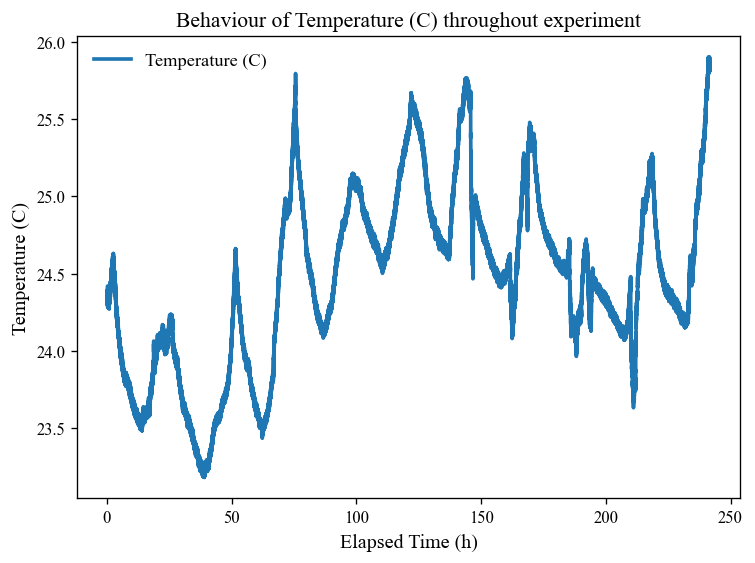

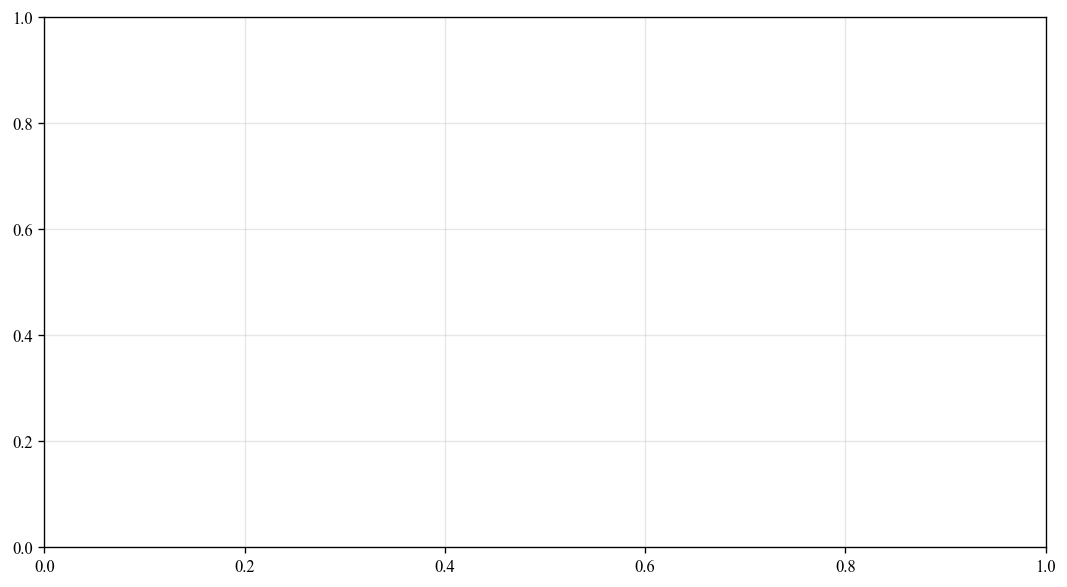

In [17]:
main_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release.csv"   # has Time, Pressure, Temp

df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
temperature_col = "calibrated temperature (C)"
time_col = "Time (s)"

t_h = pd.to_numeric(df_main[time_col], errors="coerce")

setup_plots()  
fig, ax = plt.subplots()

# Always give meaningful labels that state *what the curve is and what it represents*
plot_line(ax, t_h, df_main[temperature_col], label="Temperature (C)")


ax.set_xlabel(r"Elapsed Time (h)")
ax.set_ylabel(r"Temperature (C)")

finalize(ax,
         title=r"Behaviour of Temperature (C) throughout experiment",
        legend_title=None,
         savepath="Behaviour of Temperature (C) vs Time (h).png")  # saved at 300+ dpi
plt.show()

plt.figure(figsize=(9,5))
# plt.plot(t_h, df_main[temperature_col], label="Temperature (C)")
# plt.xlabel("Elapsed Time (h)")
# plt.ylabel("Temperature (C)")
# plt.title("Temperature vs Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pressure in atm


<Figure size 1200x600 with 0 Axes>

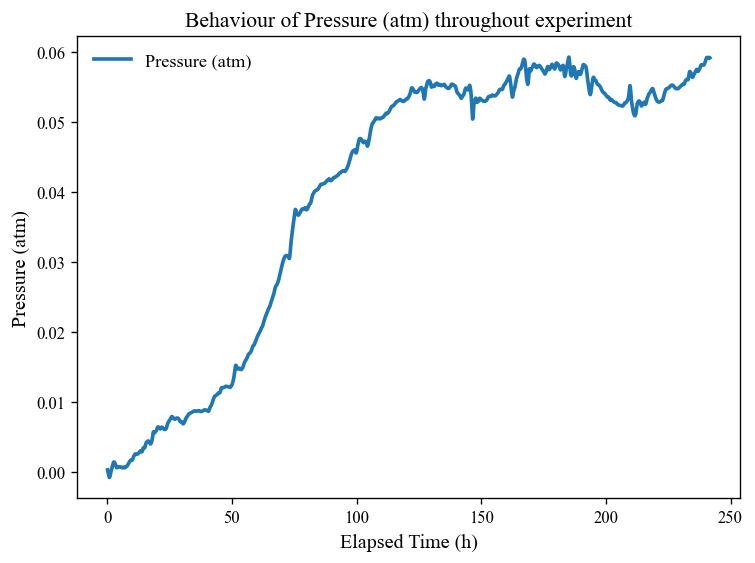

0.05928848133017262


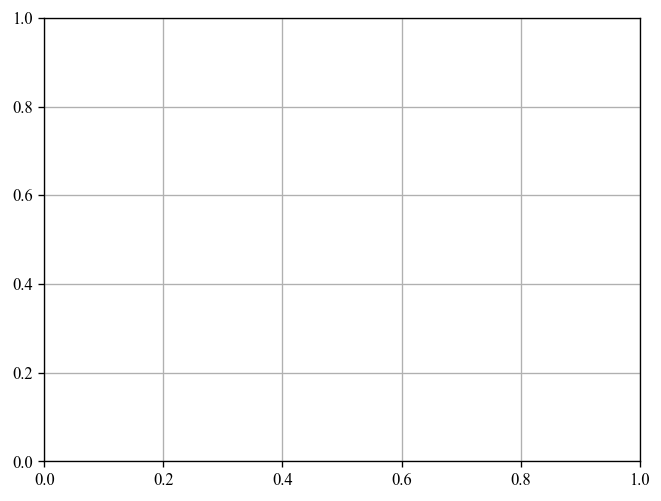

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release.csv"   # has Time, Pressure, Temp

df_main = pd.read_csv(main_csv)

df_main.columns = [c.strip() for c in df_main.columns]


pressure_col = df_main["DWT denoised pressure (kPa)"] / 101.325  # convert kPa to atm
time_col = df_main["Time (s)"] 

plt.figure(figsize=(10, 5))

setup_plots()  # do this once per kernel/session, or keep at top of plotting cells

fig, ax = plt.subplots()

# Always give meaningful labels that state *what the curve is and what it represents*
plot_line(ax, time_col, pressure_col, label= "Pressure (atm)")


ax.set_xlabel(r"Elapsed Time (h)")
ax.set_ylabel(r"Pressure (atm)")

finalize(ax,
         title=r"Behaviour of Pressure (atm) throughout experiment",
         legend_title=None,
         savepath="Behaviour of Pressure (atm) throughout experiment.png")  # saved at 300+ dpi
plt.show()

plt.grid()

print(max(pressure_col))

# Headspace o2 detected by sensor

The headspace o2 column in the csv is not accurate, the recalculated value is stored in O2_released_multi_volumes.csv

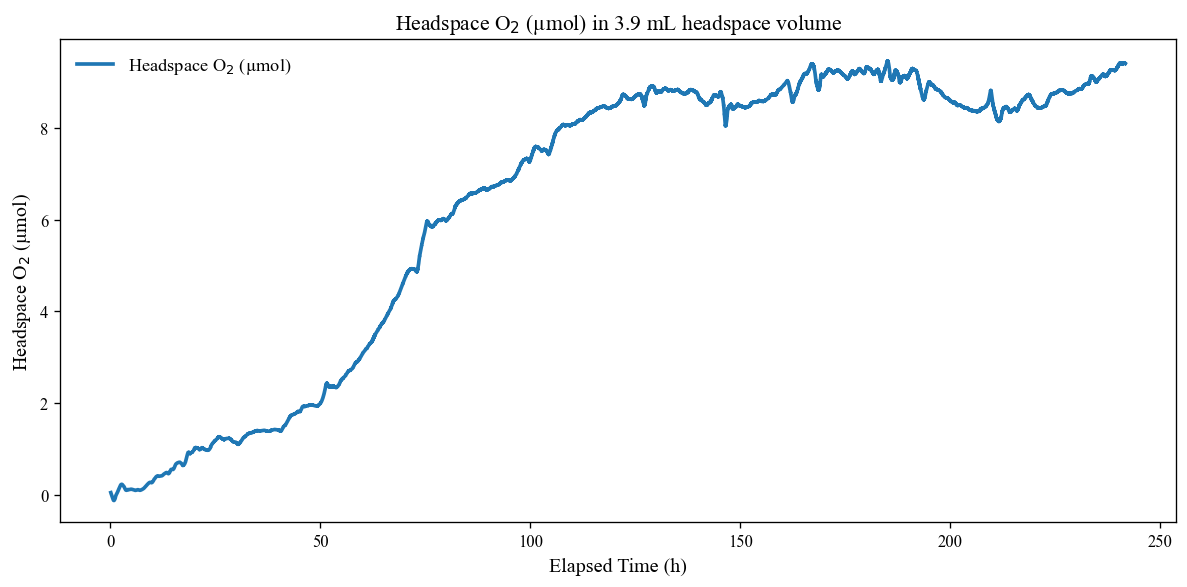

9.463833703835196


In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

main_csv = r"O2_released_multi_volumes.csv"   # has Time, Pressure, Temp
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]

headspace_oxygen = df_main["O2 Released (µmol) - Vg=3.9mL"]
time_col = df_main["Time (s)"] 

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(time_col, headspace_oxygen, label="Headspace O$_2$ (µmol)")  # converted to hours

ax.set_xlabel("Elapsed Time (h)")
ax.set_ylabel("Headspace O$_2$ (µmol)")

# Add informative plot title
title_text = "Headspace O$_2$ (µmol) in 3.9 mL headspace volume"

# Legend text with max value (no legend title)
max_val = max(headspace_oxygen)
ax.legend([f"Headspace O$_2$ (µmol)\nMax = {max_val:.2f} µmol"], frameon=False)



# finalize handles legend, title, save
finalize(ax, title=title_text, legend_title=None,savepath="headspace_o2_3p9mL.png")

plt.show()


print(max(headspace_oxygen))

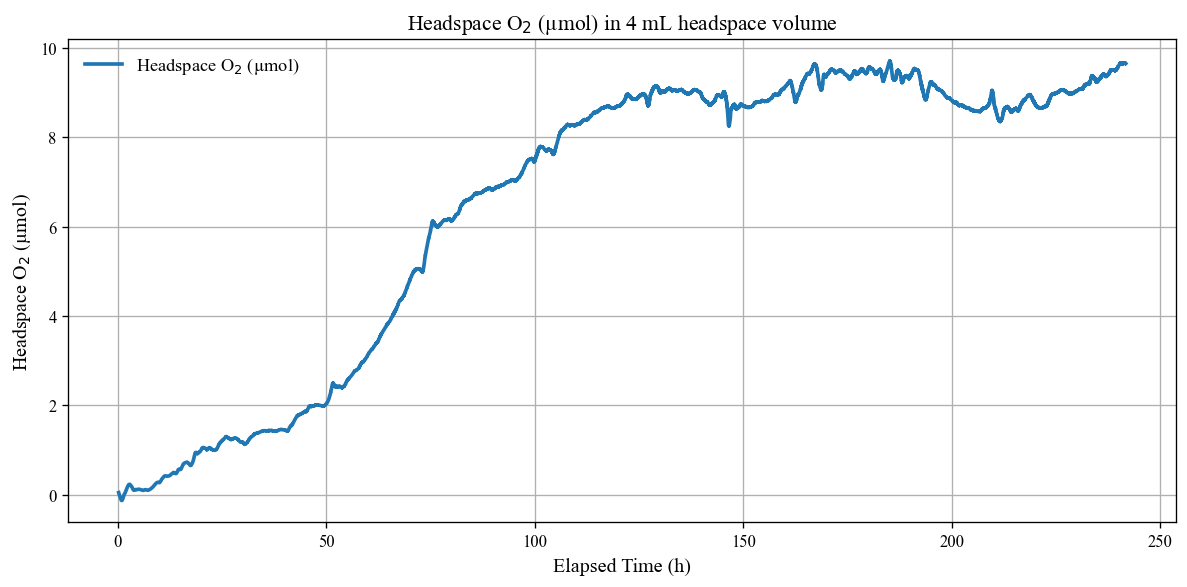

9.70649610649764


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

main_csv = r"O2_released_multi_volumes.csv"   # has Time, Pressure, Temp
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]

headspace_oxygen = df_main["O2 Released (µmol) - Vg=4.0mL"]
time_col = df_main["Time (s)"]

fig, ax = plt.subplots(figsize=(10, 5))

# plot with label
ax.plot(time_col, headspace_oxygen, label="Headspace O$_2$ (µmol)")

ax.set_xlabel("Elapsed Time (h)")   # keep as-is per your request
ax.set_ylabel("Headspace O$_2$ (µmol)")

# Add plot title
title_text = "Headspace O$_2$ (µmol) in 4 mL headspace volume"

# Legend with max O2 value included in label
max_val = max(headspace_oxygen)
ax.legend([f"Headspace O$_2$ (µmol)\nMax = {max_val:.2f} µmol"], frameon=False)

ax.grid(True)

# finalize handles formatting and saving (no legend title)
finalize(ax, title=title_text, legend_title=None, savepath="headspace_o2_4mL.png")

plt.show()

plt.show()

print(max(headspace_oxygen))

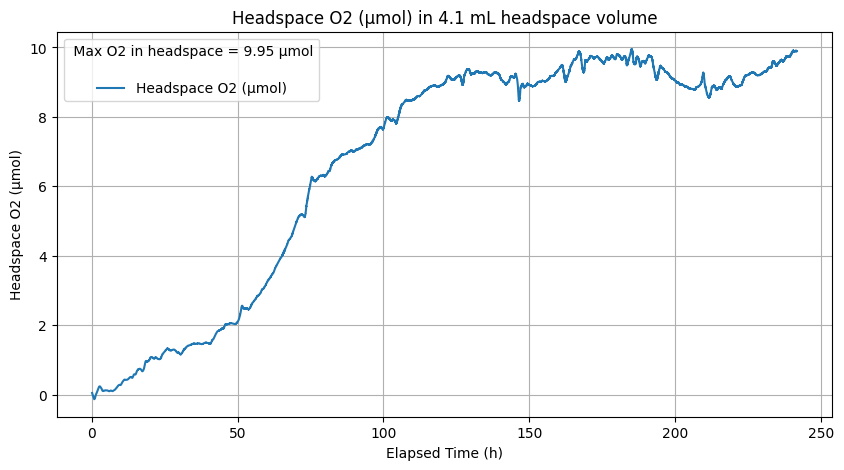

9.949158509160082


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"O2_released_multi_volumes.csv"   # has Time, Pressure, Temp
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]


headspace_oxygen = df_main["O2 Released (µmol) - Vg=4.1mL"]
time_col = df_main["Time (s)"] 



plt.figure(figsize=(10, 5))
plt.plot(time_col, headspace_oxygen, label="Headspace O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Headspace O2 (µmol)")
plt.title("Headspace O2 (µmol) in 4.1 mL headspace volume")


# Add small legend box with approach descriptions
legend_text = (
    " Max O2 in headspace = {:.2f} µmol\n"
).format(max(headspace_oxygen))
plt.legend(title=legend_text)
plt.grid()
plt.show()

print(max(headspace_oxygen))

Bottom line : If the same pressure is observed in a bigger headspace, then the number of moles of gas must be larger.(according to n = PVg / RT). so increases Vg increases n linearly.

# Dissolved O2 in atm

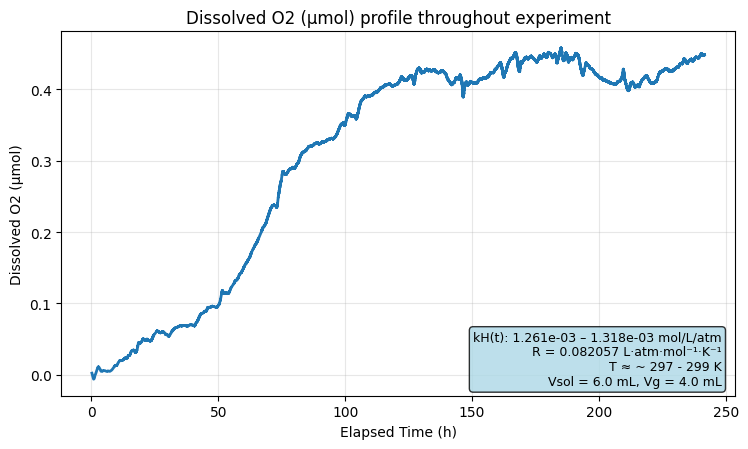

0.4578607752927767
0.4481385644717554


In [ ]:
#code for dissolved o2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1

Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm


n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_kpa (kPa)": p_kpa,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_aq (µmol)": n_aq_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_aq (µmol)"], linewidth=2)
plt.ylabel("Dissolved O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Dissolved O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(n_aq_umol))
print(n_aq_umol.iloc[-1])

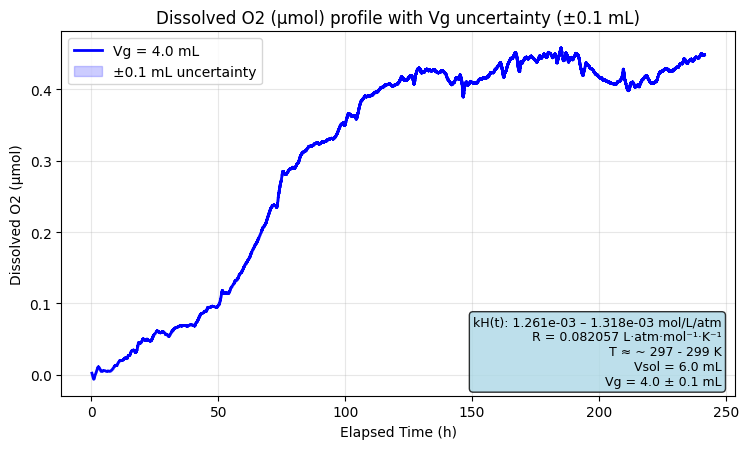

0.4578607752927767


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


main_csv   = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  


R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg_center = 0.0040      # L (4.0 mL)
Vg_low    = 0.0039      # L (3.9 mL)
Vg_high   = 0.0041      # L (4.1 mL)


df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_h = pd.to_numeric(df[time_col], errors="coerce") 
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm


n_aq_center = (kH_time * Vsol * p_atm) * 1e6
n_aq_low    = (kH_time * Vsol * p_atm) * 1e6  # same formula (Vg doesn't affect n_aq directly!)
n_aq_high   = (kH_time * Vsol * p_atm) * 1e6

plt.figure(figsize=(7.6, 4.6))
plt.plot(time_h, n_aq_center, linewidth=2, color="blue", label="Vg = 4.0 mL")
plt.fill_between(time_h, n_aq_low, n_aq_high, color="blue", alpha=0.2, label="±0.1 mL uncertainty")

plt.ylabel("Dissolved O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Dissolved O2 (µmol) profile with Vg uncertainty (±0.1 mL)")
plt.legend()

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL\n"
    f"Vg = 4.0 ± 0.1 mL"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(n_aq_center))


Bottomline : Changing headspace volume Vg doesnt affect the amount of dissolved oxygen levels hence the value remains the same.

# Comparison between headspace oxygen and dissolved oxygen

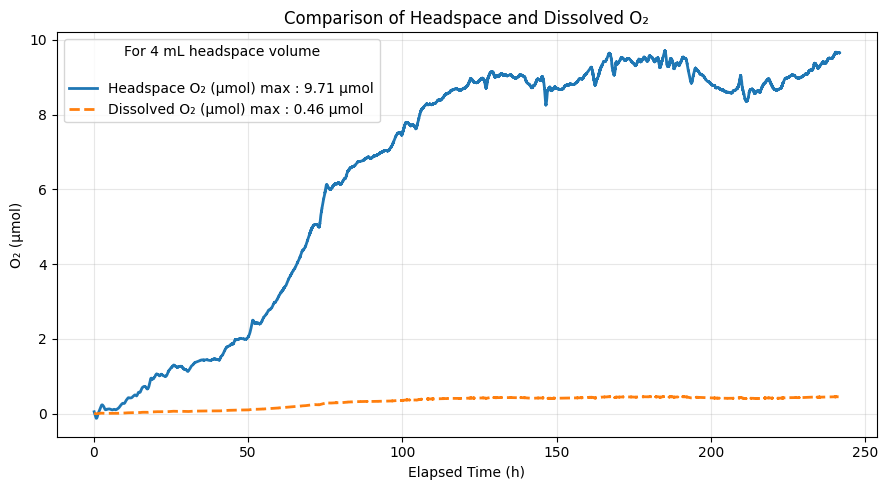

Max Headspace O2: 9.71 µmol
Max Dissolved O2: 0.46 µmol


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"O2_released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.004   # L

# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- plot both ----------
plt.figure(figsize=(9, 5))
plt.plot(time_hs, headspace_oxygen, label="Headspace O₂ (µmol) max : {:.2f} µmol".format(headspace_oxygen.max()), linewidth=2)
plt.plot(time_ds, n_aq_umol, label="Dissolved O₂ (µmol) max : {:.2f} µmol".format(n_aq_umol.max()), linewidth=2, linestyle="--")

legend_text = (
    "For 4 mL headspace volume\n"
)
plt.legend(title=legend_text)
# labels and formatting
plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace and Dissolved O₂")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max Headspace O2: {headspace_oxygen.max():.2f} µmol")
print(f"Max Dissolved O2: {n_aq_umol.max():.2f} µmol")


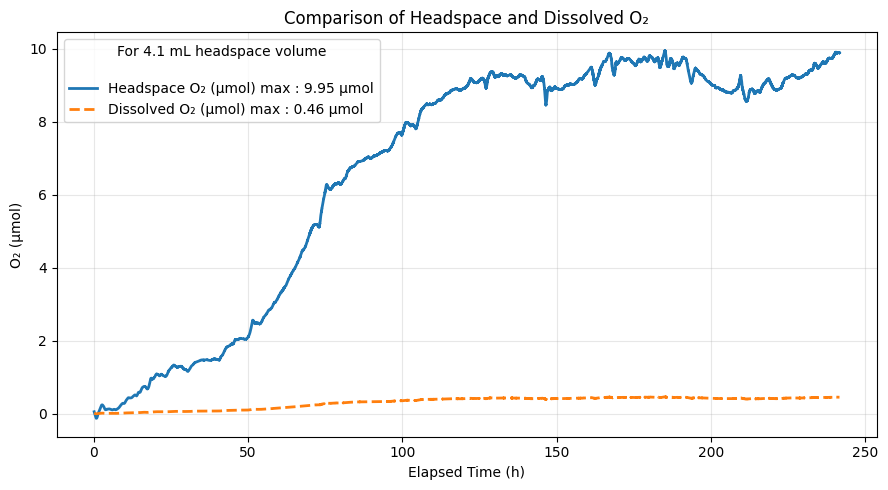

Max Headspace O2: 9.95 µmol
Max Dissolved O2: 0.46 µmol


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"O2_released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.0041   # L

# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.1mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- plot both ----------
plt.figure(figsize=(9, 5))
plt.plot(time_hs, headspace_oxygen, label="Headspace O₂ (µmol) max : {:.2f} µmol".format(headspace_oxygen.max()), linewidth=2)
plt.plot(time_ds, n_aq_umol, label="Dissolved O₂ (µmol) max : {:.2f} µmol".format(n_aq_umol.max()), linewidth=2, linestyle="--")

legend_text = (
    "For 4.1 mL headspace volume\n"
)
plt.legend(title=legend_text)
# labels and formatting
plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace and Dissolved O₂")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max Headspace O2: {headspace_oxygen.max():.2f} µmol")
print(f"Max Dissolved O2: {n_aq_umol.max():.2f} µmol")


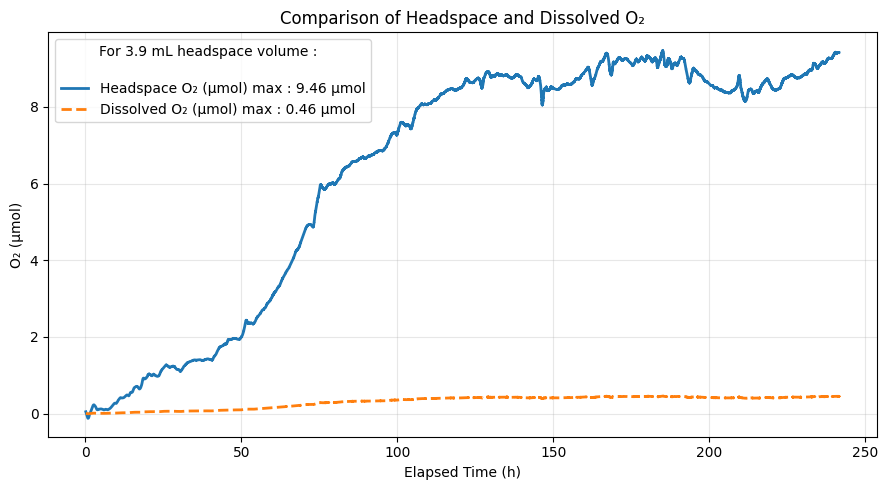

Max Headspace O2: 9.46 µmol
Max Dissolved O2: 0.46 µmol


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"O2_released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.0039   # L

# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=3.9mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- plot both ----------
plt.figure(figsize=(9, 5))
plt.plot(time_hs, headspace_oxygen, label="Headspace O₂ (µmol) max : {:.2f} µmol".format(headspace_oxygen.max()), linewidth=2)
plt.plot(time_ds, n_aq_umol, label="Dissolved O₂ (µmol) max : {:.2f} µmol".format(n_aq_umol.max()), linewidth=2, linestyle="--")

legend_text = (
    "For 3.9 mL headspace volume :  \n"
)

plt.legend(title=legend_text)
# labels and formatting
plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace and Dissolved O₂")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max Headspace O2: {headspace_oxygen.max():.2f} µmol")
print(f"Max Dissolved O2: {n_aq_umol.max():.2f} µmol")


# Comparing total oxygen released with dissolved oxygen and headspace oxygen :



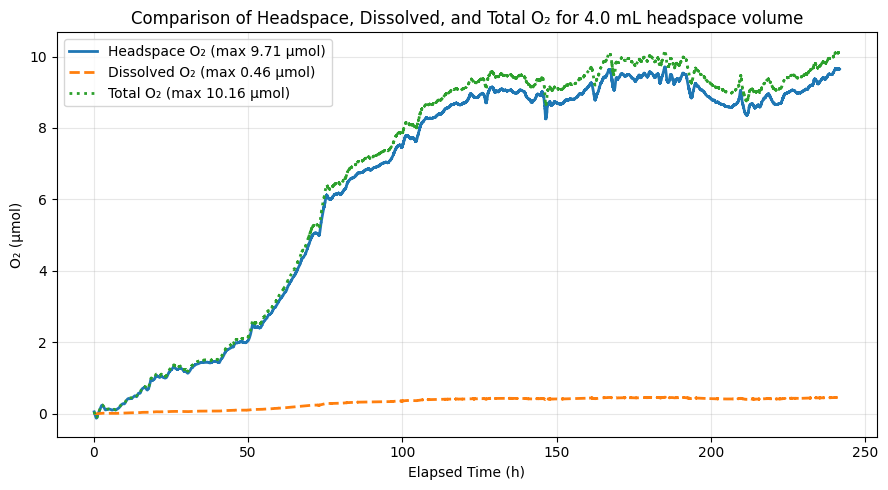

Final Headspace O₂: 9.65 µmol
Final Dissolved O₂: 0.45 µmol
Final Total O₂: 10.10 µmol


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"O2_released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.004   # L


# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- align time if necessary ----------
n = min(len(time_hs), len(headspace_oxygen), len(time_ds), len(n_aq_umol))
time = time_hs.iloc[:n].reset_index(drop=True)
headspace_oxygen = headspace_oxygen.iloc[:n].reset_index(drop=True)
n_aq_umol = n_aq_umol.iloc[:n].reset_index(drop=True)

# ---------- total O2 ----------
n_total_umol = headspace_oxygen + n_aq_umol

plt.figure(figsize=(9, 5))
plt.plot(time, headspace_oxygen, label=f"Headspace O₂ (max {headspace_oxygen.max():.2f} µmol)", linewidth=2)
plt.plot(time, n_aq_umol, label=f"Dissolved O₂ (max {n_aq_umol.max():.2f} µmol)", linewidth=2, linestyle="--")
plt.plot(time, n_total_umol, label=f"Total O₂ (max {n_total_umol.max():.2f} µmol)", linewidth=2, linestyle=":")

plt.legend(loc="upper left")


plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace, Dissolved, and Total O₂ for 4.0 mL headspace volume")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




print(f"Final Headspace O₂: {headspace_oxygen.iloc[-1]:.2f} µmol")
print(f"Final Dissolved O₂: {n_aq_umol.iloc[-1]:.2f} µmol")
print(f"Final Total O₂: {n_total_umol.iloc[-1]:.2f} µmol")


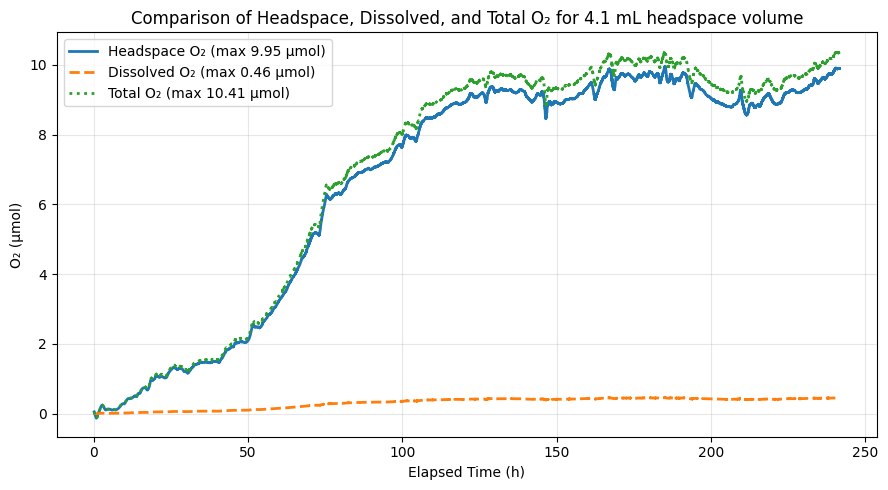

Final Headspace O₂: 9.89 µmol
Final Dissolved O₂: 0.45 µmol
Final Total O₂: 10.34 µmol


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"O2_released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.0041   # L


# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.1mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- align time if necessary ----------
n = min(len(time_hs), len(headspace_oxygen), len(time_ds), len(n_aq_umol))
time = time_hs.iloc[:n].reset_index(drop=True)
headspace_oxygen = headspace_oxygen.iloc[:n].reset_index(drop=True)
n_aq_umol = n_aq_umol.iloc[:n].reset_index(drop=True)

# ---------- total O2 ----------
n_total_umol = headspace_oxygen + n_aq_umol

plt.figure(figsize=(9, 5))
plt.plot(time, headspace_oxygen, label=f"Headspace O₂ (max {headspace_oxygen.max():.2f} µmol)", linewidth=2)
plt.plot(time, n_aq_umol, label=f"Dissolved O₂ (max {n_aq_umol.max():.2f} µmol)", linewidth=2, linestyle="--")
plt.plot(time, n_total_umol, label=f"Total O₂ (max {n_total_umol.max():.2f} µmol)", linewidth=2, linestyle=":")

plt.legend(loc="upper left")


plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace, Dissolved, and Total O₂ for 4.1 mL headspace volume")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




print(f"Final Headspace O₂: {headspace_oxygen.iloc[-1]:.2f} µmol")
print(f"Final Dissolved O₂: {n_aq_umol.iloc[-1]:.2f} µmol")
print(f"Final Total O₂: {n_total_umol.iloc[-1]:.2f} µmol")


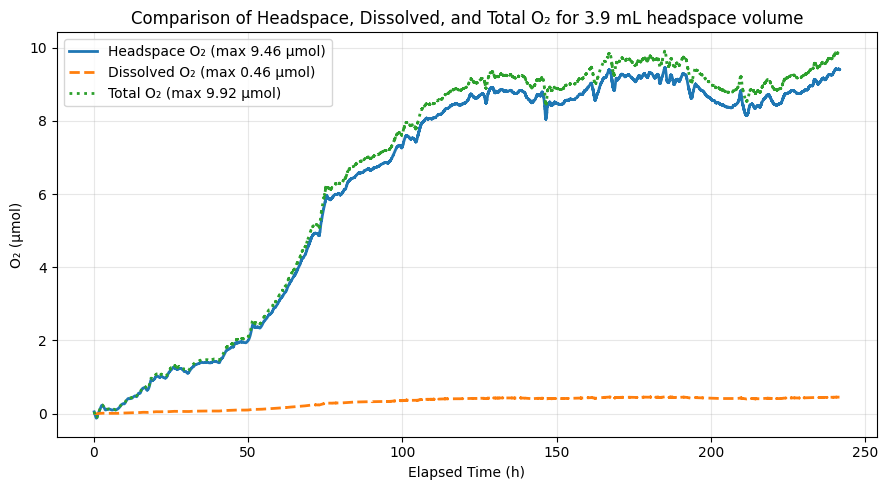

Final Headspace O₂: 9.41 µmol
Final Dissolved O₂: 0.45 µmol
Final Total O₂: 9.86 µmol


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"O2_released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.0039   # L


# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=3.9mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- align time if necessary ----------
n = min(len(time_hs), len(headspace_oxygen), len(time_ds), len(n_aq_umol))
time = time_hs.iloc[:n].reset_index(drop=True)
headspace_oxygen = headspace_oxygen.iloc[:n].reset_index(drop=True)
n_aq_umol = n_aq_umol.iloc[:n].reset_index(drop=True)

# ---------- total O2 ----------
n_total_umol = headspace_oxygen + n_aq_umol

plt.figure(figsize=(9, 5))
plt.plot(time, headspace_oxygen, label=f"Headspace O₂ (max {headspace_oxygen.max():.2f} µmol)", linewidth=2)
plt.plot(time, n_aq_umol, label=f"Dissolved O₂ (max {n_aq_umol.max():.2f} µmol)", linewidth=2, linestyle="--")
plt.plot(time, n_total_umol, label=f"Total O₂ (max {n_total_umol.max():.2f} µmol)", linewidth=2, linestyle=":")

plt.legend(loc="upper left")


plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace, Dissolved, and Total O₂ for 3.9 mL headspace volume")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




print(f"Final Headspace O₂: {headspace_oxygen.iloc[-1]:.2f} µmol")
print(f"Final Dissolved O₂: {n_aq_umol.iloc[-1]:.2f} µmol")
print(f"Final Total O₂: {n_total_umol.iloc[-1]:.2f} µmol")


# Total oxygen released

# For 4mL

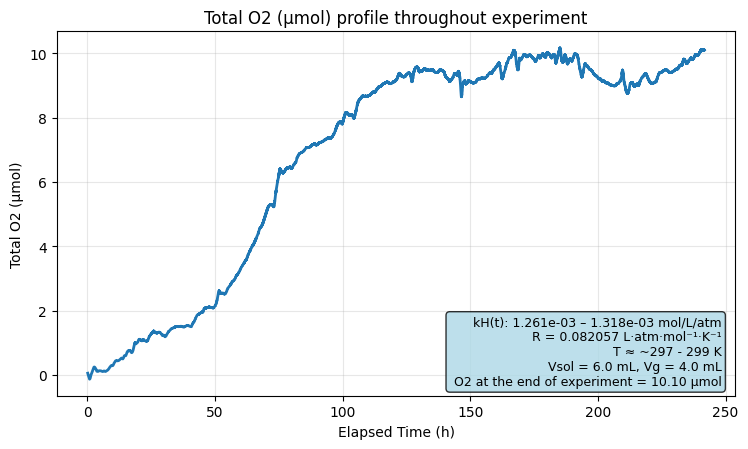

10.164356881790416
10.097963136432714


In [44]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")



p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f" O2 at the end of experiment = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(max(ntot_umol))
print(ntot_umol.iloc[-1])

The maximum observed O₂ was 10.16 µmol, while the final value at the end of the experiment was 10.10 µmol. The slight decrease reflects temperature-driven changes and/or experimental losses or oxygen going back to dissolved stage at the end

## Okay the problem is, in the original csv file, the O2 Released (µmol) was calculated by using 2ml headspace as the Vg. it has to be changed now for 4 mL

In [ ]:
import pandas as pd

# ---------- Constants ----------
R = 0.082057  # L⋅atm/(mol⋅K)
V_headspace_volumes = [0.0039, 0.004, 0.0041]  # L (3.9, 4.0, 4.1 mL headspace)

input_csv = r"M2_2.18mM_pressure_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"

df = pd.read_csv(input_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

# Extract data
pressure_kpa = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")
pressure_atm = pressure_kpa / 101.325

# Create output dataframe starting with original data
df_output = df.copy()

# Calculate O2 for each headspace volume
for V_headspace in V_headspace_volumes:
    n_o2_mol = (pressure_atm * V_headspace) / (R * temp)
    n_o2_umol = n_o2_mol * 1e6
    
    # Create column name with volume in mL
    column_name = f"O2 Released (µmol) - Vg={V_headspace*1000:.1f}mL"
    df_output[column_name] = n_o2_umol

# Save to CSV
output_csv = "O2_released_multi_volumes.csv"
df_output.to_csv(output_csv, index=False)

print(f"Saved to: {output_csv}")


Conversion complete for 3 volumes!
Vg = 3.9 mL: Max O2 = 9.46 µmol
Vg = 4.0 mL: Max O2 = 9.71 µmol
Vg = 4.1 mL: Max O2 = 9.95 µmol
Saved to: O2_released_multi_volumes.csv


# Approach 2 
# Ntotal = nheadspace (detected by sensor) + naq

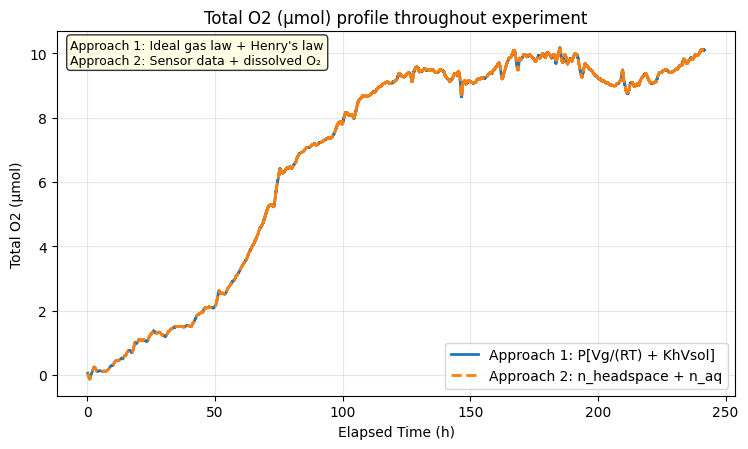

10.164356881790416
10.164356881790416


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
headspace_csv = r"O2_released_4ml.csv"
# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
df_headspace = pd.read_csv(headspace_csv)
df_headspace.columns = [c.strip() for c in df_headspace.columns]




time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")
n_headspace = pd.to_numeric(df_headspace["O2 Released (µmol) - Calculated"], errors="coerce")


p_atm = p_kpa / 101.325    # convert kPa to atm



#approach 1
def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol_approach1 = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# approach 2
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6
n_total_umol_approach2 = n_headspace + n_aq_umol

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol) 1": ntot_umol_approach1,
    "n_total(µmol) 2": n_total_umol_approach2

})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol) 1"], linewidth=2, label="Approach 1: P[Vg/(RT) + KhVsol]")
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol) 2"], linewidth=2, label="Approach 2: n_headspace + n_aq", linestyle="--")

# Add small legend box with approach descriptions
legend_text = (
    "Approach 1: Ideal gas law + Henry's law\n"
    "Approach 2: Sensor data + dissolved O₂"
)
plt.text(0.02, 0.98, legend_text,
         transform=plt.gca().transAxes,
         va="top", ha="left", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))






plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

#label
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(ntot_umol_approach1))
print(max(n_total_umol_approach2))


The above is just a comparison between both methods to establish that they both will give the same results eitherway so its better to stick to one

# For 3.9mL

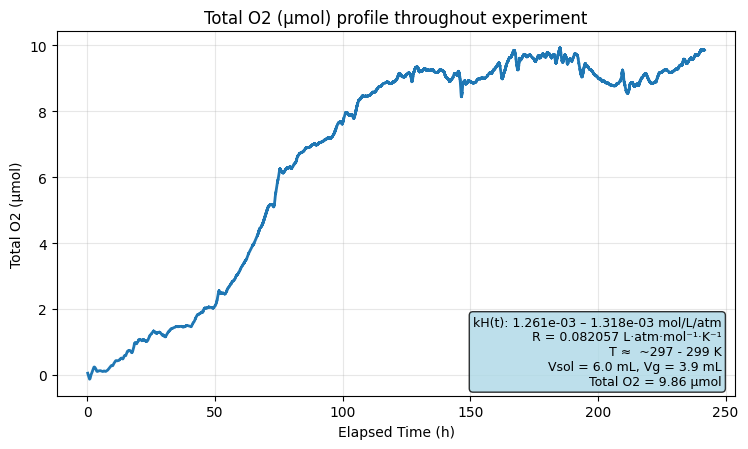

9.921694479127975
9.856717522133689


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.0039            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")



p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈  ~297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Total O2 = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(max(ntot_umol))
print(ntot_umol.iloc[-1])

# For 4.1mL

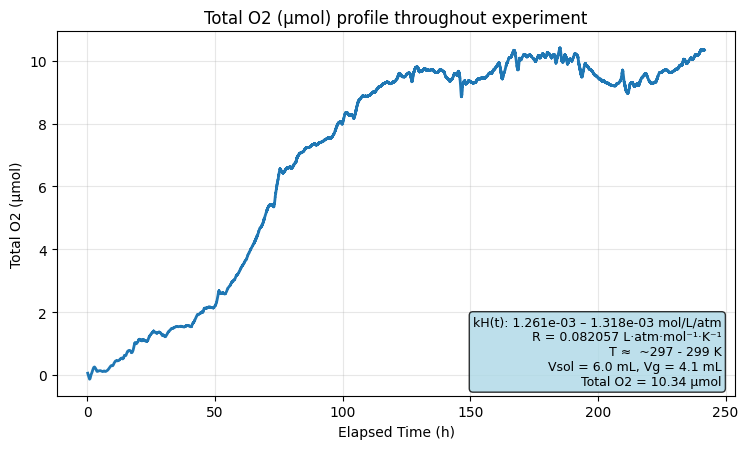

10.407019284452858
10.33920875073174


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.0041           # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")



p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈  ~297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Total O2 = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(max(ntot_umol))
print(ntot_umol.iloc[-1])

## For Vg = 3.9mL : Total O2 released is (max) 9.921694479127975 
## For Vg = 4.0mL : Total O2 released is (max) 10.164356881790416
## For Vg = 4.1mL : Total O2 released is (max) 10.407019284452858  


# With uncertainity

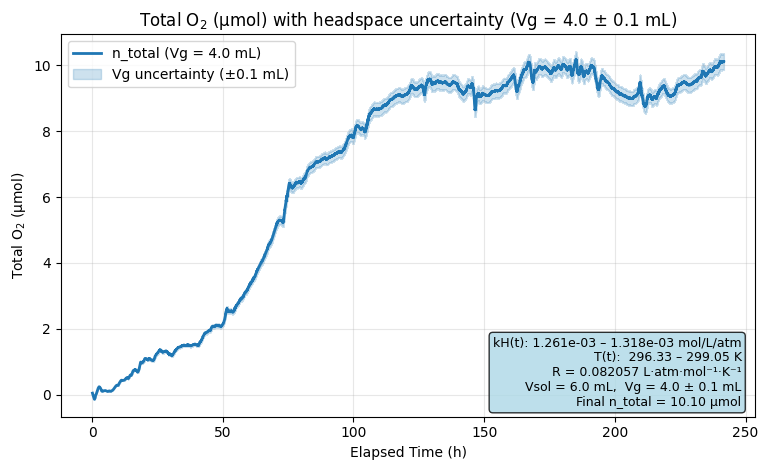

Max n_total (center): 10.164356881790416
Final n_total (center): 10.097963136432714


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"
press_col  = "DWT denoised pressure (kPa)"

# ---------- constants ----------
R    = 0.082057      # L·atm·mol^-1·K^-1
Vsol = 0.006         # L
Vg_center = 0.0040   # L (4.0 mL)
Vg_low    = 0.0039   # L (3.9 mL)
Vg_high   = 0.0041   # L (4.1 mL)

# ---------- load ----------
df    = pd.read_csv(main_csv)
df_kh = pd.read_csv(kh_csv)
df.columns    = [c.strip() for c in df.columns]
df_kh.columns = [c.strip() for c in df_kh.columns]

# parse & align
time_h  = pd.to_numeric(df[time_col], errors="coerce") 
p_kpa   = pd.to_numeric(df[press_col], errors="coerce")
p_atm   = p_kpa / 101.325
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")

n = min(len(time_h), len(p_atm), len(kH_time), len(T_time))
time_h, p_atm, kH_time, T_time = [s.iloc[:n].reset_index(drop=True) for s in (time_h, p_atm, kH_time, T_time)]

# ---------- n_total for different Vg (µmol) ----------
def n_total_umol(p_atm, Vg, Vsol, R, T, kH):
    A = (Vg / (R * T)) + (kH * Vsol)         # mol/atm
    return (p_atm * A) * 1e6                 # µmol

ntot_center = n_total_umol(p_atm, Vg_center, Vsol, R, T_time, kH_time)
ntot_low    = n_total_umol(p_atm, Vg_low,    Vsol, R, T_time, kH_time)
ntot_high   = n_total_umol(p_atm, Vg_high,   Vsol, R, T_time, kH_time)

# ---------- plot with uncertainty band ----------
plt.figure(figsize=(7.8, 4.8))
plt.plot(time_h, ntot_center, color="C0", lw=2, label="n_total (Vg = 4.0 mL)")
plt.fill_between(time_h, ntot_low, ntot_high, color="C0", alpha=0.22, label="Vg uncertainty (±0.1 mL)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Total O$_2$ (µmol)")
plt.title("Total O$_2$ (µmol) with headspace uncertainty (Vg = 4.0 ± 0.1 mL)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

# info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
T_min,  T_max  = float(np.nanmin(T_time)),  float(np.nanmax(T_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"T(t):  {T_min:.2f} – {T_max:.2f} K\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"Vsol = {Vsol*1000:.1f} mL,  Vg = 4.0 ± 0.1 mL\n"
    f"Final n_total = {ntot_center.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         ha="right", va="bottom", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

print("Max n_total (center):", float(np.nanmax(ntot_center)))
print("Final n_total (center):", float(ntot_center.iloc[-1]))


# Comparison of total oxygen released (dissolved + headspace) plot with theoretical max 13.08

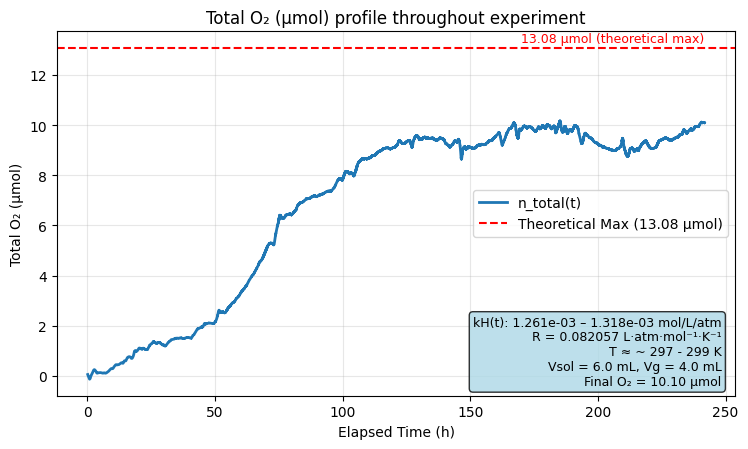

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total (µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2, label="n_total(t)")
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (13.08 µmol)")

# Put label near the top-right corner
plt.text(df_out["Elapsed Time (h)"].max(), n_theory+0.1,
         f"{n_theory} µmol (theoretical max)", color="red",
         ha="right", va="bottom", fontsize=9)

plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile throughout experiment")
plt.legend()

# Info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Final O₂ = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Foe 3.9 and 4.1 mL

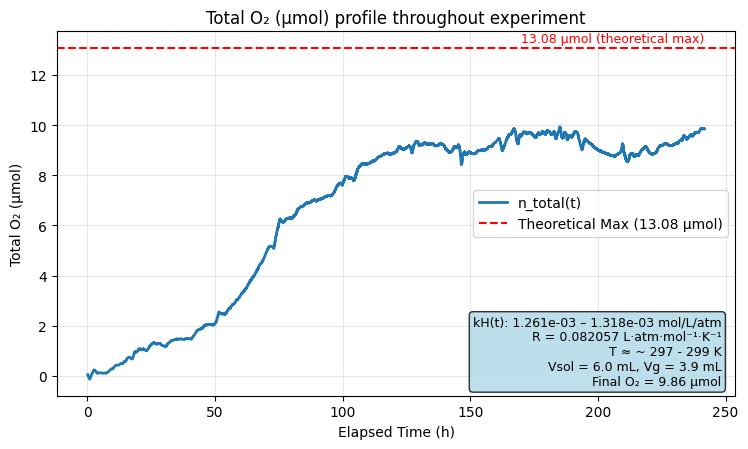

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.0039            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total (µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2, label="n_total(t)")
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (13.08 µmol)")

# Put label near the top-right corner
plt.text(df_out["Elapsed Time (h)"].max(), n_theory+0.1,
         f"{n_theory} µmol (theoretical max)", color="red",
         ha="right", va="bottom", fontsize=9)

plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile throughout experiment")
plt.legend()

# Info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Final O₂ = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


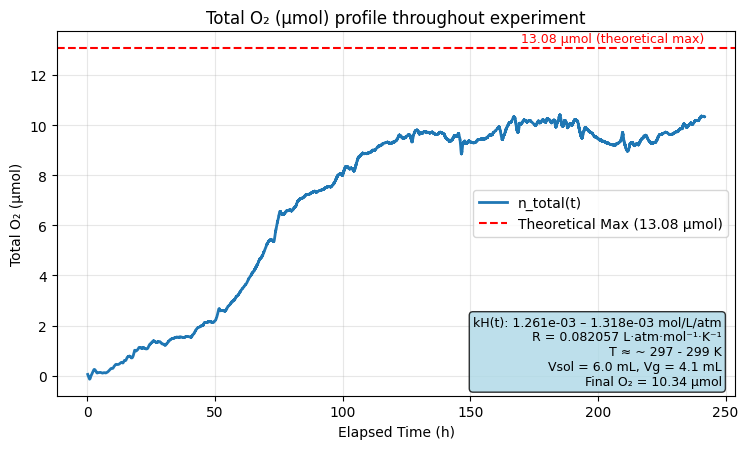

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.0041            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total (µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2, label="n_total(t)")
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (13.08 µmol)")

# Put label near the top-right corner
plt.text(df_out["Elapsed Time (h)"].max(), n_theory+0.1,
         f"{n_theory} µmol (theoretical max)", color="red",
         ha="right", va="bottom", fontsize=9)

plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile throughout experiment")
plt.legend()

# Info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Final O₂ = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


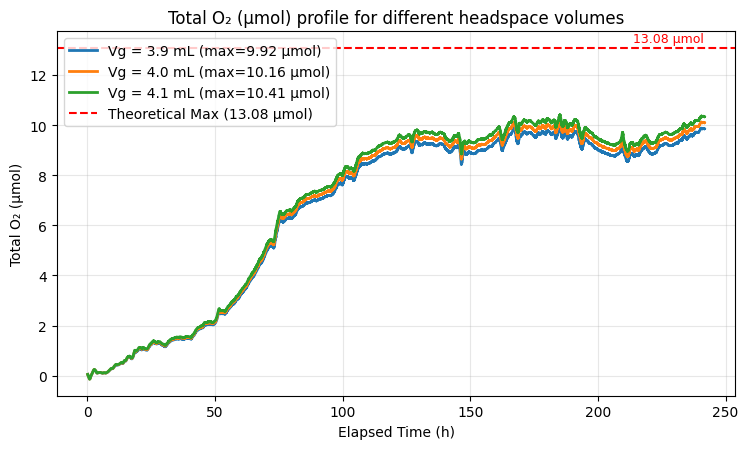

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg_values = [0.0039, 0.0040, 0.0041]  # L (3.9, 4.0, 4.1 mL)
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

T_time  = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")
time_h  = pd.to_numeric(df[time_col], errors="coerce")
p_kpa   = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm   = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))

# Plot for each Vg value
for Vg in Vg_values:
    ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)
    plt.plot(time_h, ntot_umol, linewidth=2, label=f"Vg = {Vg*1000:.1f} mL (max={ntot_umol.max():.2f} µmol)")

# Add theoretical max line
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (13.08 µmol)")
plt.text(time_h.max(), n_theory+0.1,
         f"{n_theory} µmol", color="red",
         ha="right", va="bottom", fontsize=9)

# Labels and title
plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile for different headspace volumes")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Comparison of dissolved oxygen and headspace oxygen plots

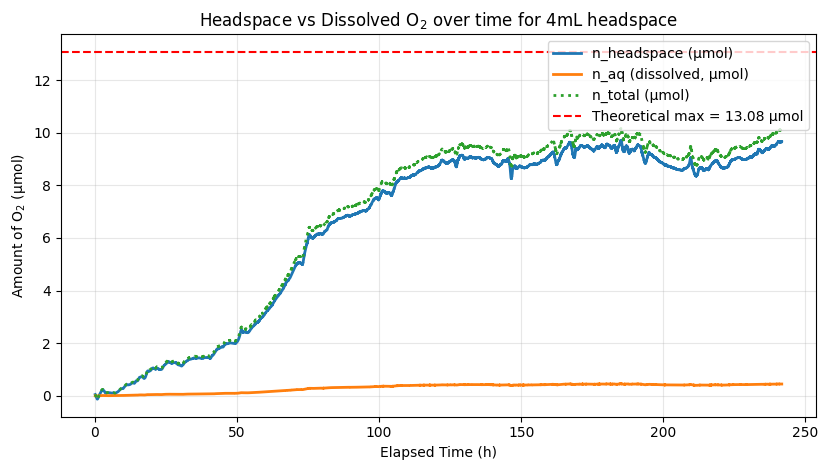

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_released_multi_volumes.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]


T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

n_headspace = pd.to_numeric(df["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# Dissolved O2 from Henry’s law (µmol)
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6


n_total_umol = n_headspace + n_aq_umol

# ---- Plot both on one figure ----
plt.figure(figsize=(8.4, 4.8))
plt.plot(time_h, n_headspace, lw=2, label="n_headspace (µmol)")
plt.plot(time_h, n_aq_umol, lw=2, label="n_aq (dissolved, µmol)")
plt.plot(time_h, n_total_umol, lw=2, label="n_total (µmol)", linestyle=":")
plt.axhline(n_theory, ls="--", c="red", lw=1.5, label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Amount of O$_2$ (µmol)")
plt.title("Headspace vs Dissolved O$_2$ over time for 4mL headspace")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_headspace (µmol)": n_headspace,
    "n_aq (µmol)": n_aq_umol,
    "n_total (µmol)": n_total_umol
})


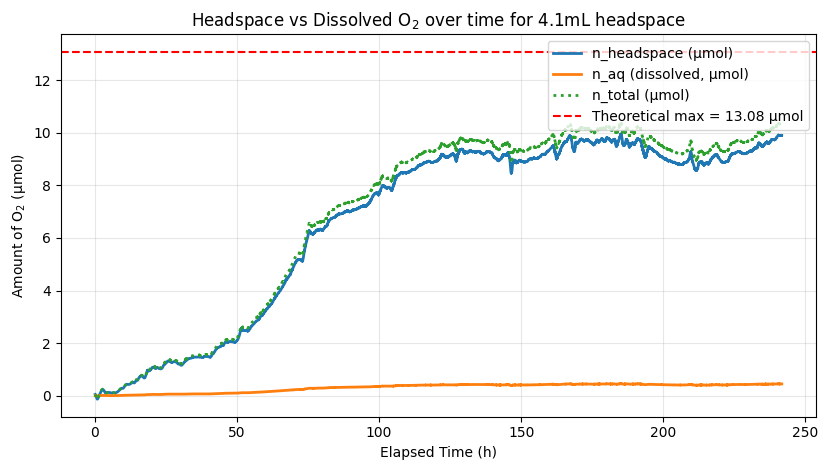

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_released_multi_volumes.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.0041            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]


T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

n_headspace = pd.to_numeric(df["O2 Released (µmol) - Vg=4.1mL"], errors="coerce")

# Dissolved O2 from Henry’s law (µmol)
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6


n_total_umol = n_headspace + n_aq_umol

# ---- Plot both on one figure ----
plt.figure(figsize=(8.4, 4.8))
plt.plot(time_h, n_headspace, lw=2, label="n_headspace (µmol)")
plt.plot(time_h, n_aq_umol, lw=2, label="n_aq (dissolved, µmol)")
plt.plot(time_h, n_total_umol, lw=2, label="n_total (µmol)", linestyle=":")
plt.axhline(n_theory, ls="--", c="red", lw=1.5, label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Amount of O$_2$ (µmol)")
plt.title("Headspace vs Dissolved O$_2$ over time for 4.1mL headspace")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_headspace (µmol)": n_headspace,
    "n_aq (µmol)": n_aq_umol,
    "n_total (µmol)": n_total_umol
})

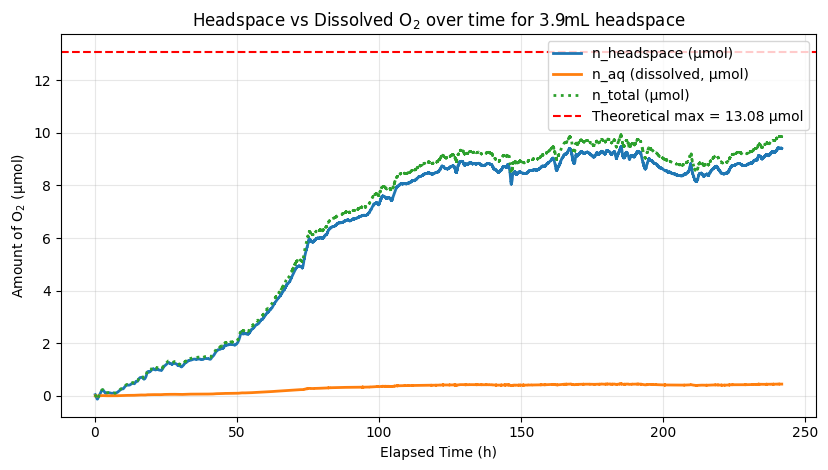

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_released_multi_volumes.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]


T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

n_headspace = pd.to_numeric(df["O2 Released (µmol) - Vg=3.9mL"], errors="coerce")

# Dissolved O2 from Henry’s law (µmol)
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6


n_total_umol = n_headspace + n_aq_umol

# ---- Plot both on one figure ----
plt.figure(figsize=(8.4, 4.8))
plt.plot(time_h, n_headspace, lw=2, label="n_headspace (µmol)")
plt.plot(time_h, n_aq_umol, lw=2, label="n_aq (dissolved, µmol)")
plt.plot(time_h, n_total_umol, lw=2, label="n_total (µmol)", linestyle=":")
plt.axhline(n_theory, ls="--", c="red", lw=1.5, label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Amount of O$_2$ (µmol)")
plt.title("Headspace vs Dissolved O$_2$ over time for 3.9mL headspace")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_headspace (µmol)": n_headspace,
    "n_aq (µmol)": n_aq_umol,
    "n_total (µmol)": n_total_umol
})

# To save the ntotal umol into a csv file (for pressure predictor) ( just for 4 mL)

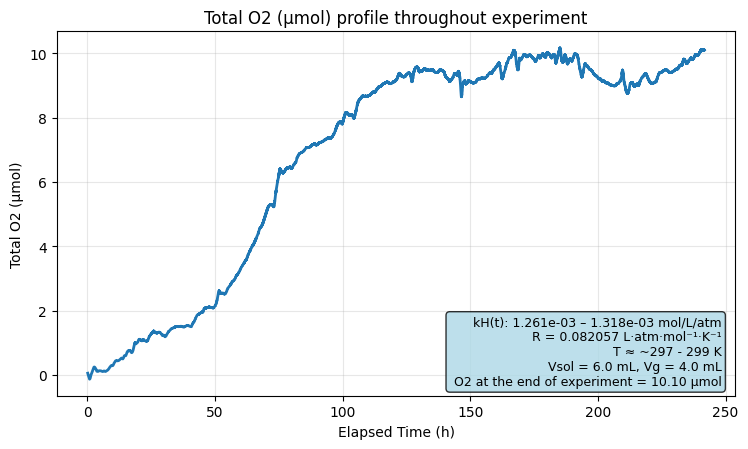

✅ Saved ntotal data to ntotal_output_RT.csv


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release.csv"     
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs -RT\Vant hoff modelling\henry's constants.csv"
# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")



p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f" O2 at the end of experiment = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- save to CSV ----------
output_csv = r"ntotal_output_RT.csv"
df_out.to_csv(output_csv, index=False)
print(f"✅ Saved ntotal data to {output_csv}")


# Pressure predictor with streamlit for other geometries 

refer to file : Change in pressure wrt geometry.py